<a href="https://colab.research.google.com/github/gamal-zayed/Quantized-Low-Rank-Adaptation-Parameter-Efficient-Fine-Tuning/blob/main/Efficiency_Curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q trl peft bitsandbytes evaluate accelerate rouge_score bert_score

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 10.9 MB/s eta 0:00:00


In [ ]:
# %% ==================== CELL 1: SETUP (run once) ====================
from google.colab import drive
drive.mount('/content/drive')

import os, gc, json, time, torch
import pandas as pd
import numpy as np
from collections import Counter
from transformers import (
    AutoConfig, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset
import evaluate
from tqdm import tqdm

MODEL_ID = "microsoft/Phi-3-mini-4k-instruct"
RANK = 8
SEED = 42
TARGET_MODULES = ["gate_up_proj", "down_proj"]   # "MLP only" — the real fused
                                                   # module names on Phi-3-mini.
DRIVE_ROOT = "/content/drive/MyDrive/exp_4_4_mlp_only"
os.makedirs(DRIVE_ROOT, exist_ok=True)

# ---- corrected fused-module parameter formula ----
PER_LAYER_COEF = {"qkv_proj": 7680, "o_proj": 6144, "gate_up_proj": 19456, "down_proj": 11264}
NUM_LAYERS = 32
def predicted_trainable_params(target_modules, r):
    return sum(PER_LAYER_COEF[m] for m in target_modules) * NUM_LAYERS * r

predicted = predicted_trainable_params(TARGET_MODULES, RANK)
print(f"MLP-only target_modules={TARGET_MODULES}, r={RANK}")
print(f"Predicted trainable params (fused-module formula): {predicted:,}")
print("Brief's own table claims ~33.74M for this row — trust "
      "print_trainable_parameters() over that figure; the brief's Section 4.4 "
      "table doesn't reconcile with its own Section 5 formula for any of its "
      "four rows, so this is very likely an error in the brief, not your setup.")
def audit_dtypes(model, label=""):
    all_dtypes = Counter(p.dtype for p in model.parameters())
    trainable_dtypes = Counter(p.dtype for p in model.parameters() if p.requires_grad)
    print(f"--- dtype audit {label} --- all: {dict(all_dtypes)} trainable: {dict(trainable_dtypes)}")
    return not any(p.requires_grad and p.dtype == torch.bfloat16 for p in model.parameters())

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=False)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

raw_dataset = load_dataset("keivalya/MedQuad-MedicalQnADataset", split="train")

def make_splits(seed, n_train=1500): #THINKING OF 500
    # n_train=1500 by default given time constraints seen earlier in this
    # project — bump back to 5000 if you have the hours to spare.
    shuffled = raw_dataset.shuffle(seed=seed)
    return shuffled.select(range(n_train)), shuffled.select(range(5000, 5500))

def formatting_prompts_func(examples):
    q_types = examples.get('qtype', [''] * len(examples[list(examples.keys())[0]]))
    questions = examples.get('Question', examples.get('question'))
    answers = examples.get('Answer', examples.get('answer'))
    texts = []
    for qt, q, a in zip(q_types, questions, answers):
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
            {"role": "assistant", "content": a}
        ]
        texts.append(tokenizer.apply_chat_template(messages, tokenize=False))
    return {"text": texts}

QUALITATIVE_PROBES = [
    "What is the first-line treatment for hypertension in a diabetic patient?",
    "What are the symptoms of type 2 diabetes?",
    "What causes rheumatoid arthritis?",
    "How is pneumonia diagnosed?",
    "What is the recommended treatment for a urinary tract infection?",
]

print("Cell 1 setup complete.")

Mounted at /content/drive
MLP-only target_modules=['gate_up_proj', 'down_proj'], r=8
Predicted trainable params (fused-module formula): 7,864,320
Brief's own table claims ~33.74M for this row — trust print_trainable_parameters() over that figure; the brief's Section 4.4 table doesn't reconcile with its own Section 5 formula for any of its four rows, so this is very likely an error in the brief, not your setup.


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.44k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/233 [00:00<?, ?B/s]

medDataset_processed.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16407 [00:00<?, ? examples/s]

Cell 1 setup complete.


In [ ]:
# # %% ==================== CELL 2: TRAINING (LoRA + DoRA) ====================
# # This is the long cell. Trains two configs: standard LoRA and DoRA
# # (use_dora=True), both at r=8, MLP-only. Safe to re-run — already
# # completed configs are skipped automatically.

# def train_one_config(rank=RANK, seed=SEED, target_modules=TARGET_MODULES,
#                       alpha_ratio=2, use_dora=False, n_train=1500):
#     method_name = "dora" if use_dora else "lora"
#     run_name = f"mlp_only_{method_name}_r{rank}_seed{seed}"
#     adapter_dir = os.path.join(DRIVE_ROOT, run_name)
#     meta_path = os.path.join(adapter_dir, "meta.json")

#     if os.path.exists(meta_path):
#         print(f"SKIPPING {run_name}ru — already completed, found on Drive.")
#         with open(meta_path) as f:
#             return json.load(f)

#     print(f"\n{'='*60}\nTRAINING: {method_name.upper()}  rank={rank}  seed={seed}\n{'='*60}")

#     from accelerate.state import AcceleratorState, PartialState
#     AcceleratorState._reset_state()
#     PartialState._reset_state()

#     train_dataset, val_dataset = make_splits(seed, n_train=n_train)
#     train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
#     val_dataset = val_dataset.map(formatting_prompts_func, batched=True)

#     bnb_config = BitsAndBytesConfig(
#         load_in_4bit=True, bnb_4bit_quant_type="nf4",
#         bnb_4bit_compute_dtype=torch.float16, # Gradient Checkpointing?
#         bnb_4bit_use_double_quant=True,  # I need to make sure Batch Size = 4
#     )

#     config = AutoConfig.from_pretrained(MODEL_ID)
#     config._attn_implementation = "sdpa"   # revert to "eager" here if this throws
#                                             # a rotary-embedding-related error

#     base_model = AutoModelForCausalLM.from_pretrained(
#         MODEL_ID, config=config, quantization_config=bnb_config,
#         device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
#     )
#     base_model.config.use_cache = False
#     base_model = prepare_model_for_kbit_training(base_model)

#     peft_kwargs = dict(
#         r=rank, lora_alpha=rank * alpha_ratio, target_modules=target_modules,
#         lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
#     )
#     if use_dora:
#         peft_kwargs["use_dora"] = True
#         # Known risk: DoRA + 4-bit quantized base has had compatibility issues
#         # in some peft versions. If this raises an error mentioning
#         # quantization/DoRA incompatibility, try: !pip install -U peft
#     peft_config = LoraConfig(**peft_kwargs)

#     try:
#         model = get_peft_model(base_model, peft_config)
#     except Exception as e:
#         print(f"get_peft_model failed for use_dora={use_dora}: {e}")
#         print("If this mentions quantization/DoRA incompatibility, upgrade peft "
#               "(!pip install -U peft) and restart the runtime, then retry.")
#         raise

#     ok = audit_dtypes(model, label=f"({method_name}, r={rank}, seed={seed})")
#     if not ok:
#         for p in model.parameters():
#             if p.requires_grad and p.dtype == torch.bfloat16:
#                 p.data = p.data.to(torch.float16)

#     trainable_actual = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"Predicted: {predicted:,} | Actual: {trainable_actual:,}")

#     out_dir = f"{DRIVE_ROOT}/{run_name}"
#     training_config = SFTConfig(
#         output_dir=out_dir,
#         dataset_text_field="text",
#         max_length=384,# was 512: modest speedup, medical answers rarely need more
#         packing=False,
#         per_device_train_batch_size=8,
#         gradient_accumulation_steps=1,   # if this OOMs: batch_size=4, accum=2
#         learning_rate=2e-4,
#         num_train_epochs=1, #WAS 3,
#         logging_steps=10,
#         eval_strategy="epoch",
#         save_strategy="steps",
#         save_steps=50,
#         fp16=False, bf16=False,
#         optim="paged_adamw_8bit",
#         seed=seed,
#         report_to=[],
#     )
#     training_config._n_gpu = 1

#     trainer = SFTTrainer(
#         model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
#         processing_class=tokenizer, args=training_config,
#     )

#     resume = os.path.isdir(out_dir) and any(d.startswith("checkpoint-") for d in os.listdir(out_dir))
#     if resume:
#         print(f"Found existing checkpoint in {out_dir} — resuming.")

#     t0 = time.time()
#     trainer.train(resume_from_checkpoint=resume)
#     wall_time = time.time() - t0
#     val_loss = trainer.evaluate()["eval_loss"]

#     model.save_pretrained(adapter_dir)
#     tokenizer.save_pretrained(adapter_dir)

#     meta = {
#         "strategy": "mlp_only", "method": method_name,
#         "rank": rank, "seed": seed, "target_modules": target_modules,
#         "use_dora": use_dora,
#         "trainable_params_predicted": predicted,
#         "trainable_params_actual": trainable_actual,
#         "wall_time_sec": wall_time, "val_loss": val_loss,
#         "adapter_dir": adapter_dir,
#     }
#     with open(meta_path, "w") as f:
#         json.dump(meta, f, indent=2)

#     del trainer, model, base_model
#     gc.collect(); torch.cuda.empty_cache()
#     return meta


# # Train both configs. Safe to re-run this cell if it crashes partway —
# # completed configs are skipped, and in-progress ones resume from their
# # last local checkpoint (unless the whole runtime disconnected, in which
# # case that one config restarts, same as we saw in Experiment 4.3).
# lora_meta = train_one_config(use_dora=False)
# print("LoRA done:", lora_meta)

# RUN_DORA = False  # flip to True only if you have time left after checking Cell 3 results
# print(pd.DataFrame([lora_meta])[
#     ["method", "rank", "trainable_params_actual", "wall_time_sec", "val_loss"]])

# if RUN_DORA:
#     dora_meta = train_one_config(use_dora=True)
#     print(pd.DataFrame([dora_meta])[["method","rank","trainable_params_actual","wall_time_sec","val_loss"]])
#     print("\nTraining complete for both LoRA and DoRA configs.")
# else:
#     print("\nTraining complete for LoRA config.")

In [ ]:
# # %% ==================== CELL 3: EVAL (run any time after Cell 2) ====================
# # Loads the base model once, evaluates both saved adapters (LoRA + DoRA)
# # with ROUGE-L, BERTScore, and the qualitative probe questions.

# from bert_score import utils as bs_utils  # noqa: ensure import path exists

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True, bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
# )
# config = AutoConfig.from_pretrained(MODEL_ID)
# config._attn_implementation = "sdpa"

# print("Loading base model once for all eval runs...")
# base_model = AutoModelForCausalLM.from_pretrained(
#     MODEL_ID, config=config, quantization_config=bnb_config,
#     device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
# )
# base_model.config.use_cache = True   # needed for generate()

# rouge = evaluate.load("rouge")

# # Fix for OverflowError: int too big to convert (DeBERTa tokenizer has no
# # model_max_length set, defaults to an unbounded sentinel that newer
# # `tokenizers` versions overflow on). Intercept AutoTokenizer.from_pretrained
# # globally so any tokenizer loaded anywhere — including inside bert_score's
# # internals — gets clamped to a sane value.
# from transformers import AutoTokenizer as _AutoTokenizer
# _orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__
# def _clamped_from_pretrained(cls, *args, **kwargs):
#     tok = _orig_from_pretrained(cls, *args, **kwargs)
#     if getattr(tok, "model_max_length", 0) > 100000:
#         print(f"Clamping absurd model_max_length -> 512 for tokenizer from "
#               f"{args[0] if args else kwargs.get('pretrained_model_name_or_path')}")
#         tok.model_max_length = 512
#     return tok
# _AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)

# bertscore = evaluate.load("bertscore")

# def make_val_split(seed):
#     shuffled = raw_dataset.shuffle(seed=seed)
#     return shuffled.select(range(5000, 5500))

# def evaluate_adapter(adapter_dir, n_eval=10):  #EDITTED n_eval WAS 20
#     with open(os.path.join(adapter_dir, "meta.json")) as f:
#         meta = json.load(f)

#     print(f"\nEvaluating {adapter_dir}  ({meta['method']}, r={meta['rank']})")
#     model = PeftModel.from_pretrained(base_model, adapter_dir)
#     model.eval()

#     val_dataset = make_val_split(meta["seed"]).select(range(n_eval))
#     references, predictions = [], []
#     for sample in tqdm(val_dataset, desc="generating"):
#         ref = sample.get('Answer', sample.get('answer', ''))
#         references.append(ref)
#         qt = sample.get('qtype', '')
#         q = sample.get('Question', sample.get('question', ''))
#         messages = [
#             {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
#             {"role": "user", "content": f"Context: {qt}. Question: {q}"},
#         ]
#         prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#         inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
#         with torch.no_grad():
#             out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
#         decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
#         predictions.append(decoded.strip())

#     rouge_res = rouge.compute(predictions=predictions, references=references)
#     bert_res = bertscore.compute(predictions=predictions, references=references,
#                                   model_type="microsoft/deberta-xlarge-mnli")

#     # qualitative probes for the write-up
#     qualitative = []
#     for q in QUALITATIVE_PROBES:
#         messages = [
#             {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
#             {"role": "user", "content": q},
#         ]
#         prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#         inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
#         with torch.no_grad():
#             out = model.generate(**inputs, max_new_tokens=200, do_sample=False)
#         decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
#         qualitative.append({"question": q, "answer": decoded.strip()})

#     with open(os.path.join(adapter_dir, "qualitative.json"), "w") as f:
#         json.dump(qualitative, f, indent=2)

#     model = model.unload()

#     meta["rougeL"] = rouge_res["rougeL"]
#     meta["bertscore_f1"] = float(np.mean(bert_res["f1"]))
#     return meta


# adapter_dirs = sorted(
#     os.path.join(DRIVE_ROOT, d) for d in os.listdir(DRIVE_ROOT)
#     if os.path.isdir(os.path.join(DRIVE_ROOT, d))
# )
# results = [evaluate_adapter(d) for d in adapter_dirs]

# df = pd.DataFrame(results)
# df.to_csv(os.path.join(DRIVE_ROOT, "exp_4_4_lora_vs_dora_results.csv"), index=False)
# print(df[["method", "rank", "trainable_params_actual", "wall_time_sec",
#           "val_loss", "rougeL", "bertscore_f1"]])
# print(f"\nSaved to {DRIVE_ROOT}/exp_4_4_lora_vs_dora_results.csv")
# print("Compare val_loss/rougeL/bertscore_f1 between the lora and dora rows — "
#       "that comparison IS the exceptional-tier deliverable per Section 12.3. "
#       "Check qualitative.json in each adapter's folder for example answers "
#       "to quote in your write-up.")

This cell is meant for an approxiumate extension. Best when completing all Experiment 3 and 4, then go to Experiment#5
-
Experiment 5: Data Efficiency Curve
-

In [ ]:
# %% ============ CELL 4: EXPERIMENT 5 — DATA EFFICIENCY CURVE (TRAINING) ============
# Uses your validated best config: MLP-only target_modules, r=8, plain LoRA.
# (Rank chosen per the brief's own Exp-3 conclusion — r=8 captures most of the
# gain of higher ranks — so we don't need to re-run the rank ablation here.)
#
# Trains one adapter per subset size. Safe to re-run: completed sizes are
# skipped automatically, same pattern as Cell 2.



DRIVE_ROOT_EXP5 = "/content/drive/MyDrive/exp_4_5_data_efficiency"
os.makedirs(DRIVE_ROOT_EXP5, exist_ok=True)

# BEST_TARGET_MODULES = ["gate_up_proj", "down_proj"]   # MLP-only winner (your Exp 4)
# BEST_RANK = 8
BEST_TARGET_MODULES = ["qkv_proj", "o_proj", "gate_up_proj", "down_proj"]  # attention_mlp — Exp4 winner
BEST_RANK = 16   # Exp3 winner


# Full brief asks for [500, 1000, 2500, 5000, 10000]. Given tonight's deadline,
# 10000 alone costs ~3 hours, so it's dropped by default (~2.5h total instead
# of ~5.3h). If you're even tighter on time, cut to just [500, 2500, 5000]
# (~2.2h) -- the diminishing-returns shape is already visible with 3 points.
DATA_SIZES = [500, 1000, 2500, 5000, 10000]

def make_splits_exp5(seed, n_train):
    # FIX: validation is now the LAST 500 shuffled samples, fixed regardless
    # of n_train. This guarantees no train/val overlap even at n_train=10000
    # (your original make_splits() used a fixed range(5000,5500), which would
    # have silently leaked into the training set for n_train > 5000).
    shuffled = raw_dataset.shuffle(seed=seed)
    n_total = len(shuffled)
    val_dataset = shuffled.select(range(n_total - 500, n_total))
    train_dataset = shuffled.select(range(n_train))
    return train_dataset, val_dataset

def train_data_efficiency_point(n_train, rank=BEST_RANK, seed=SEED,
                                 target_modules=BEST_TARGET_MODULES):
    run_name = f"data_eff_n{n_train}_r{rank}_seed{seed}"
    adapter_dir = os.path.join(DRIVE_ROOT_EXP5, run_name)
    meta_path = os.path.join(adapter_dir, "meta.json")

    if os.path.exists(meta_path):
        print(f"SKIPPING n_train={n_train} — already completed, found on Drive.")
        with open(meta_path) as f:
            return json.load(f)

    print(f"\n{'='*60}\nTRAINING: data-efficiency point  n_train={n_train}\n{'='*60}")

    from accelerate.state import AcceleratorState, PartialState
    AcceleratorState._reset_state()
    PartialState._reset_state()

    train_dataset, val_dataset = make_splits_exp5(seed, n_train)
    train_dataset = train_dataset.map(formatting_prompts_func, batched=True)
    val_dataset = val_dataset.map(formatting_prompts_func, batched=True)

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    config = AutoConfig.from_pretrained(MODEL_ID)
    config._attn_implementation = "sdpa"

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, config=config, quantization_config=bnb_config,
        device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
    )
    base_model.config.use_cache = False
    base_model = prepare_model_for_kbit_training(base_model)

    peft_config = LoraConfig(
        r=rank, lora_alpha=rank * 2, target_modules=target_modules,
        lora_dropout=0.05, bias="none", task_type="CAUSAL_LM",
    )
    model = get_peft_model(base_model, peft_config)

    ok = audit_dtypes(model, label=f"(data_eff, n_train={n_train})")
    if not ok:
        for p in model.parameters():
            if p.requires_grad and p.dtype == torch.bfloat16:
                p.data = p.data.to(torch.float16)

    trainable_actual = sum(p.numel() for p in model.parameters() if p.requires_grad)

    out_dir = f"{DRIVE_ROOT_EXP5}/_checkpoints/{run_name}"
    training_config = SFTConfig(
        output_dir=out_dir,
        dataset_text_field="text",
        max_length=384,
        packing=False,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=1,
        learning_rate=2e-4,
        num_train_epochs=1,          # trimmed from brief's implicit default given time constraints
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="steps",
        save_steps=50,
        fp16=False, bf16=False,
        optim="paged_adamw_8bit",
        seed=seed,
        report_to=[],
    )
    training_config._n_gpu = 1

    trainer = SFTTrainer(
        model=model, train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, args=training_config,
    )

    resume = os.path.isdir(out_dir) and any(d.startswith("checkpoint-") for d in os.listdir(out_dir))
    if resume:
        print(f"Found existing checkpoint in {out_dir} — resuming.")

    t0 = time.time()
    trainer.train(resume_from_checkpoint=resume)
    wall_time = time.time() - t0
    val_loss = trainer.evaluate()["eval_loss"]

    model.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    meta = {
        "experiment": "data_efficiency", "n_train": n_train,
        "rank": rank, "seed": seed, "target_modules": target_modules,
        "trainable_params_actual": trainable_actual,
        "wall_time_sec": wall_time, "val_loss": val_loss,
        "adapter_dir": adapter_dir,
    }
    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    del trainer, model, base_model
    gc.collect(); torch.cuda.empty_cache()
    return meta


data_eff_results = []
for n in DATA_SIZES:
    data_eff_results.append(train_data_efficiency_point(n))

print("\nData efficiency training complete.")
print(pd.DataFrame(data_eff_results)[["n_train", "trainable_params_actual", "wall_time_sec", "val_loss"]])

SKIPPING n_train=500 — already completed, found on Drive.
SKIPPING n_train=1000 — already completed, found on Drive.
SKIPPING n_train=2500 — already completed, found on Drive.
SKIPPING n_train=5000 — already completed, found on Drive.
SKIPPING n_train=10000 — already completed, found on Drive.

Data efficiency training complete.
   n_train  trainable_params_actual  wall_time_sec  val_loss
0      500                 25165824     696.436321  0.938501
1     1000                 25165824    1251.892255  0.882538
2     2500                 25165824    1045.102368  0.838284
3     5000                 25165824    1834.365344  0.802192
4    10000                 25165824   10297.143264  0.769820


Loading base model once for all Exp-5 eval runs...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]


Evaluating n_train=10000
Skipping data_eff_n10000_r16_seed42
Repo id must be in the form 'repo_name' or 'namespace/repo_name': '/content/drive/MyDrive/exp_4_5_data_efficiency/data_eff_n10000_r16_seed42'. Use `repo_type` argument if needed.

Evaluating n_train=1000


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(
generating:   0%|          | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
generating: 100%|██████████| 10/10 [01:48<00:00, 10.85s/it]


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   6678 MiB |   6895 MiB | 681029 MiB | 674351 MiB |
|       from large pool |   6319 MiB |   6421 MiB | 573370 MiB | 567050 MiB |
|       from small pool |    358 MiB |    520 MiB | 107659 MiB | 107300 MiB |
|---------------------------------------------------------------------------|
| Active memory         |   6678 MiB |   6895 MiB | 681029 MiB | 674351 MiB |
|       from large pool |   6319 MiB |   6421 MiB | 573370 MiB |

...

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   9121 MiB |   9512 MiB |   1413 GiB |   1404 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   1189 GiB |   1180 GiB |
|       from small pool |    361 MiB |    553 MiB |    223 GiB |    223 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   9121 MiB |   9512 MiB |   1413 GiB |   1404 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   1189 GiB |


generating: 100%|██████████| 10/10 [02:09<00:00, 12.91s/it]


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   9121 MiB |   9512 MiB |   2189 GiB |   2180 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   1840 GiB |   1831 GiB |
|       from small pool |    361 MiB |    553 MiB |    349 GiB |    348 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   9121 MiB |   9512 MiB |   2189 GiB |   2180 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   1840 GiB |

generating: 100%|██████████| 10/10 [01:45<00:00, 10.54s/it]


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |   9121 MiB |   9512 MiB |   2853 GiB |   2844 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   2400 GiB |   2391 GiB |
|       from small pool |    361 MiB |    553 MiB |    453 GiB |    452 GiB |
|---------------------------------------------------------------------------|
| Active memory         |   9121 MiB |   9512 MiB |   2853 GiB |   2844 GiB |
|       from large pool |   8760 MiB |   9151 MiB |   2400 GiB |

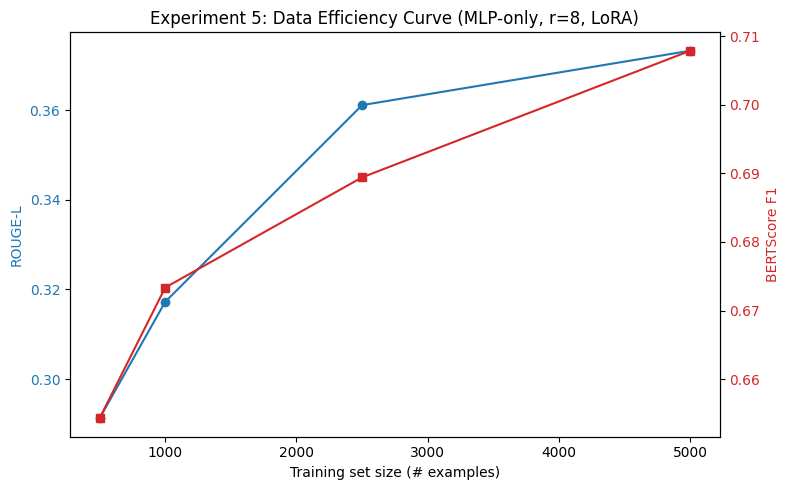


Saved plot to /content/drive/MyDrive/exp_4_5_data_efficiency/exp_4_5_data_efficiency_curve.png
Saved results to /content/drive/MyDrive/exp_4_5_data_efficiency/exp_4_5_data_efficiency_results.csv


In [ ]:
# %% ============ CELL 5: EXPERIMENT 5 — EVAL + PLOT (run any time after Cell 4) ============
# Loads the base model once, evaluates each data-efficiency adapter with
# ROUGE-L + BERTScore on the SAME fixed held-out set, then plots both
# metrics vs. training set size.

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
config = AutoConfig.from_pretrained(MODEL_ID)
config._attn_implementation = "sdpa"

print("Loading base model once for all Exp-5 eval runs...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, config=config, quantization_config=bnb_config,
    device_map={"": 0}, trust_remote_code=False, torch_dtype=torch.float16,
)
base_model.config.use_cache = True

rouge = evaluate.load("rouge")

# Same OverflowError fix as Cell 3 — needed again since this is a fresh
# runtime/session boundary in some workflows.
from transformers import AutoTokenizer as _AutoTokenizer
if not getattr(_AutoTokenizer, "_clamp_patched", False):
    _orig_from_pretrained = _AutoTokenizer.from_pretrained.__func__
    def _clamped_from_pretrained(cls, *args, **kwargs):
        tok = _orig_from_pretrained(cls, *args, **kwargs)
        if getattr(tok, "model_max_length", 0) > 100000:
            tok.model_max_length = 512
        return tok
    _AutoTokenizer.from_pretrained = classmethod(_clamped_from_pretrained)
    _AutoTokenizer._clamp_patched = True

bertscore = evaluate.load("bertscore")

# IMPORTANT: fixed eval set — must match make_splits_exp5's val split exactly
# (last 500 shuffled samples, seed=SEED) so every subset size is judged on
# the identical held-out questions. This is what makes the curve a fair
# comparison across n_train values.
def make_fixed_eval_split(seed=SEED, n_eval=10):
    shuffled = raw_dataset.shuffle(seed=seed)
    n_total = len(shuffled)
    val_dataset = shuffled.select(range(n_total - 500, n_total))
    return val_dataset.select(range(n_eval))

def evaluate_data_eff_adapter(adapter_dir, n_eval=10):
    with open(os.path.join(adapter_dir, "meta.json")) as f:
        meta = json.load(f)

    print(f"\nEvaluating n_train={meta['n_train']}")
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    eval_dataset = make_fixed_eval_split(n_eval=n_eval)
    references, predictions = [], []
    for sample in tqdm(eval_dataset, desc="generating"):
        ref = sample.get('Answer', sample.get('answer', ''))
        references.append(ref)
        qt = sample.get('qtype', '')
        q = sample.get('Question', sample.get('question', ''))
        messages = [
            {"role": "system", "content": "You are a knowledgeable medical assistant. Answer the patient's question clearly and accurately."},
            {"role": "user", "content": f"Context: {qt}. Question: {q}"},
        ]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to("cuda:0")
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=150, do_sample=False)
        decoded = tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
        predictions.append(decoded.strip())

        del inputs
        del out
        torch.cuda.empty_cache()

    # rouge_res = rouge.compute(predictions=predictions, references=references)
    # bert_res = bertscore.compute(predictions=predictions, references=references,
    #                               model_type="microsoft/deberta-xlarge-mnli")

    # model = model.unload()
    # Free the LLM before metric computation
    model = model.unload()

    del model
    torch.cuda.empty_cache()
    print(torch.cuda.memory_summary())

    gc.collect()

    rouge_res = rouge.compute(
        predictions=predictions,
        references=references
    )

    bert_res = bertscore.compute(
        predictions=predictions,
        references=references,
        model_type="microsoft/deberta-xlarge-mnli",
       #device="cpu",      # <-- important
        batch_size=2,
    )

    meta["rougeL"] = rouge_res["rougeL"]
    meta["bertscore_f1"] = float(np.mean(bert_res["f1"]))
    return meta


adapter_dirs_exp5 = sorted(
    os.path.join(DRIVE_ROOT_EXP5, d) for d in os.listdir(DRIVE_ROOT_EXP5)
    #if os.path.isdir(os.path.join(DRIVE_ROOT_EXP5, d))
    if os.path.isdir(os.path.join(DRIVE_ROOT_EXP5, d))
    and os.path.exists(os.path.join(DRIVE_ROOT_EXP5, d, "meta.json"))
)


#xp5_results = [evaluate_data_eff_adapter(d) for d in adapter_dirs_exp5]
exp5_results = []

for d in adapter_dirs_exp5:
    try:
        exp5_results.append(evaluate_data_eff_adapter(d))
    except Exception as e:
        print(f"Skipping {os.path.basename(d)}")
        print(e)


df5 = pd.DataFrame(exp5_results).sort_values("n_train")
df5.to_csv(os.path.join(DRIVE_ROOT_EXP5, "exp_4_5_data_efficiency_results.csv"), index=False)
print(df5[["n_train", "trainable_params_actual", "wall_time_sec", "val_loss", "rougeL", "bertscore_f1"]])

# ---- Plot: ROUGE-L and BERTScore vs training set size ----
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = "tab:blue"
ax1.set_xlabel("Training set size (# examples)")
ax1.set_ylabel("ROUGE-L", color=color1)
ax1.plot(df5["n_train"], df5["rougeL"], marker="o", color=color1, label="ROUGE-L")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("BERTScore F1", color=color2)
ax2.plot(df5["n_train"], df5["bertscore_f1"], marker="s", color=color2, label="BERTScore F1")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Experiment 5: Data Efficiency Curve (MLP-only, r=8, LoRA)")
fig.tight_layout()
plot_path = os.path.join(DRIVE_ROOT_EXP5, "exp_4_5_data_efficiency_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nSaved plot to {plot_path}")
print(f"Saved results to {DRIVE_ROOT_EXP5}/exp_4_5_data_efficiency_results.csv")

   n_train  trainable_params_actual  wall_time_sec  val_loss    rougeL  \
3      500                 25165824     696.436321  0.938501  0.291253   
0     1000                 25165824    1251.892255  0.882538  0.317242   
1     2500                 25165824    1045.102368  0.838284  0.361119   
2     5000                 25165824    1834.365344  0.802192  0.373256   

   bertscore_f1  
3      0.654306  
0      0.673358  
1      0.689410  
2      0.707859  


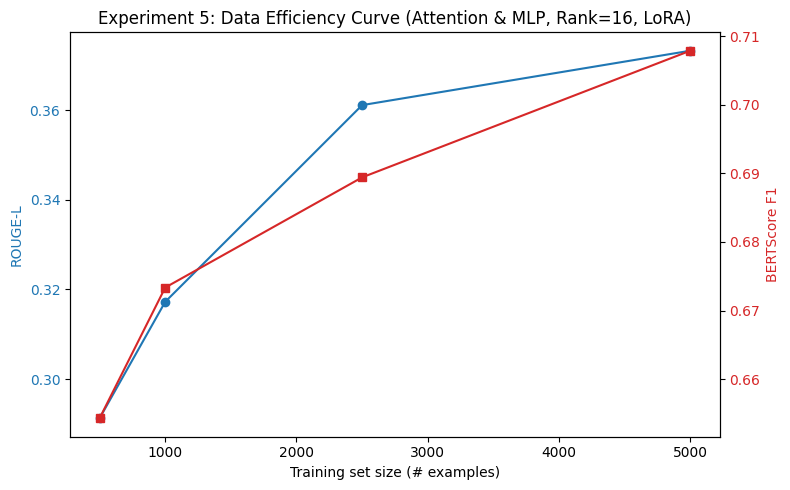


Saved plot to /content/drive/MyDrive/exp_4_5_data_efficiency/exp_4_5_data_efficiency_curve.png
Saved results to /content/drive/MyDrive/exp_4_5_data_efficiency/exp_4_5_data_efficiency_results.csv


In [ ]:
df5 = pd.DataFrame(exp5_results).sort_values("n_train")
df5.to_csv(os.path.join(DRIVE_ROOT_EXP5, "exp_4_5_data_efficiency_results.csv"), index=False)
print(df5[["n_train", "trainable_params_actual", "wall_time_sec", "val_loss", "rougeL", "bertscore_f1"]])

# ---- Plot: ROUGE-L and BERTScore vs training set size ----
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

color1 = "tab:blue"
ax1.set_xlabel("Training set size (# examples)")
ax1.set_ylabel("ROUGE-L", color=color1)
ax1.plot(df5["n_train"], df5["rougeL"], marker="o", color=color1, label="ROUGE-L")
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "tab:red"
ax2.set_ylabel("BERTScore F1", color=color2)
ax2.plot(df5["n_train"], df5["bertscore_f1"], marker="s", color=color2, label="BERTScore F1")
ax2.tick_params(axis="y", labelcolor=color2)

plt.title("Experiment 5: Data Efficiency Curve (Attention & MLP, Rank=16, LoRA)")
fig.tight_layout()
plot_path = os.path.join(DRIVE_ROOT_EXP5, "exp_4_5_data_efficiency_curve.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nSaved plot to {plot_path}")
print(f"Saved results to {DRIVE_ROOT_EXP5}/exp_4_5_data_efficiency_results.csv")